# QSAR XGBoost SHAP feature selection

This notebook performs SHAP-based feature selection for the XGBoost QSAR model. It stores per-target checkpoints and validates the selected features.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import shap
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier

MODEL_DIR = "xgboost"
MODEL_NAME = "XGBoost"

cwd = Path.cwd()
project_root = Path("..").resolve() if cwd.name == MODEL_DIR else cwd
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from qsar_config import DATA_PATH, RANDOM_SEED
from qsar_common import (
    add_mol_column,
    aggregate_targets_by_fingerprint,
    build_morgan_fingerprints,
    encode_targets,
    load_qsar_dataset,
    stack_features_and_targets,
    to_target_probability_matrix,
)

In [2]:
FPSIZE = 4096
TOP_N_PER_TARGET = 50

In [3]:
df = load_qsar_dataset(DATA_PATH)

In [4]:
df = add_mol_column(df, smiles_column="Smiles", mol_column="mol")

In [5]:
df = build_morgan_fingerprints(
    df,
    mol_column="mol",
    output_column="fp",
    radius=2,
    n_bits=FPSIZE,
)

In [6]:
df, encoder, target_names = encode_targets(
    df,
    target_column="Target",
    output_column="target_encoded",
)

In [7]:
df_agg = aggregate_targets_by_fingerprint(
    df,
    fp_column="fp",
    encoded_target_column="target_encoded",
    aggregated_target_column="target",
)

In [8]:
x, y = stack_features_and_targets(
    df_agg,
    fp_column="fp",
    target_column="target",
)

In [9]:
print(f"Data Prepared. Shape: {x.shape}")

Data Prepared. Shape: (7207, 4096)


In [10]:
n_targets = y.shape[1]
all_selected_features = set()
feature_importance_matrix = []
checkpoint_dir = Path("checkpoints") / "xgboost-shap"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

print(f"\nStarting feature selection for {n_targets} targets...")

for i in range(n_targets):
    checkpoint_file = checkpoint_dir / f"target_{target_names[i]}.npy"

    if checkpoint_file.exists():
        print(f"\n>>> [Target {target_names[i]}] Loading checkpoint: {checkpoint_file}")
        target_importance = np.load(checkpoint_file)
    else:
        print(f"\n>>> [Target {target_names[i]}] Computing feature importance...")

        y_target = y[:, i]

        xgb_target = XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            n_jobs=-1,
            random_state=42,
            tree_method="hist",
            eval_metric="logloss",
        )
        xgb_target.fit(x, y_target)

        target_importance = xgb_target.feature_importances_
        np.save(checkpoint_file, target_importance)
        print(f"    Saved checkpoint: {checkpoint_file}")

    feature_importance_matrix.append(target_importance)
    sorted_idx = np.argsort(target_importance)[::-1]
    top_n_idx = sorted_idx[:TOP_N_PER_TARGET]
    all_selected_features.update(top_n_idx)

final_selected_indices = sorted(list(all_selected_features))
print(f"\nDone. Total unique selected features: {len(final_selected_indices)}")


Starting feature selection for 6 targets...

>>> [Target ar] Computing feature importance...
    Saved checkpoint: checkpoints/xgboost-shap/target_ar.npy

>>> [Target era] Computing feature importance...
    Saved checkpoint: checkpoints/xgboost-shap/target_era.npy

>>> [Target erb] Computing feature importance...
    Saved checkpoint: checkpoints/xgboost-shap/target_erb.npy

>>> [Target gr] Computing feature importance...
    Saved checkpoint: checkpoints/xgboost-shap/target_gr.npy

>>> [Target mr] Computing feature importance...
    Saved checkpoint: checkpoints/xgboost-shap/target_mr.npy

>>> [Target pr] Computing feature importance...
    Saved checkpoint: checkpoints/xgboost-shap/target_pr.npy

Done. Total unique selected features: 238


Training final OneVsRest XGBoost model...
Generating ROC curves...


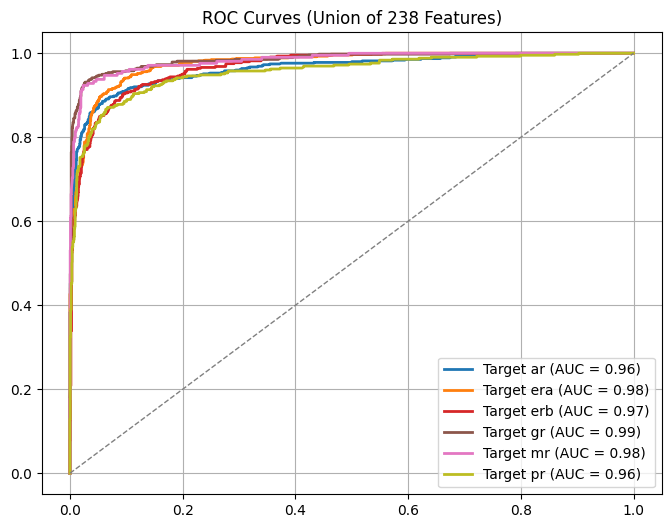

In [11]:
if len(final_selected_indices) == 0:
    print("Warning: no features selected. Using all features.")
    X_selected = x
else:
    X_selected = x[:, final_selected_indices]

x_train, x_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.3,
    random_state=RANDOM_SEED,
)

print("Training final OneVsRest XGBoost model...")
model = OneVsRestClassifier(
    XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED,
        tree_method="hist",
        eval_metric="logloss",
    )
)
model.fit(x_train, y_train)

y_pred_prob = model.predict_proba(x_test)

print("Generating ROC curves...")
plt.figure(figsize=(8, 6))
cmap = matplotlib.colormaps.get_cmap("tab10")

for i in range(n_targets):
    if len(np.unique(y_test[:, i])) > 1:
        auc_score = roc_auc_score(y_test[:, i], y_pred_prob[:, i])
        fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
        color = cmap(i / n_targets)
        plt.plot(fpr, tpr, color=color, lw=2, label=f"Target {target_names[i]} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
plt.title(f"ROC Curves (Union of {len(final_selected_indices)} Features)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Generating plots for 6 targets...


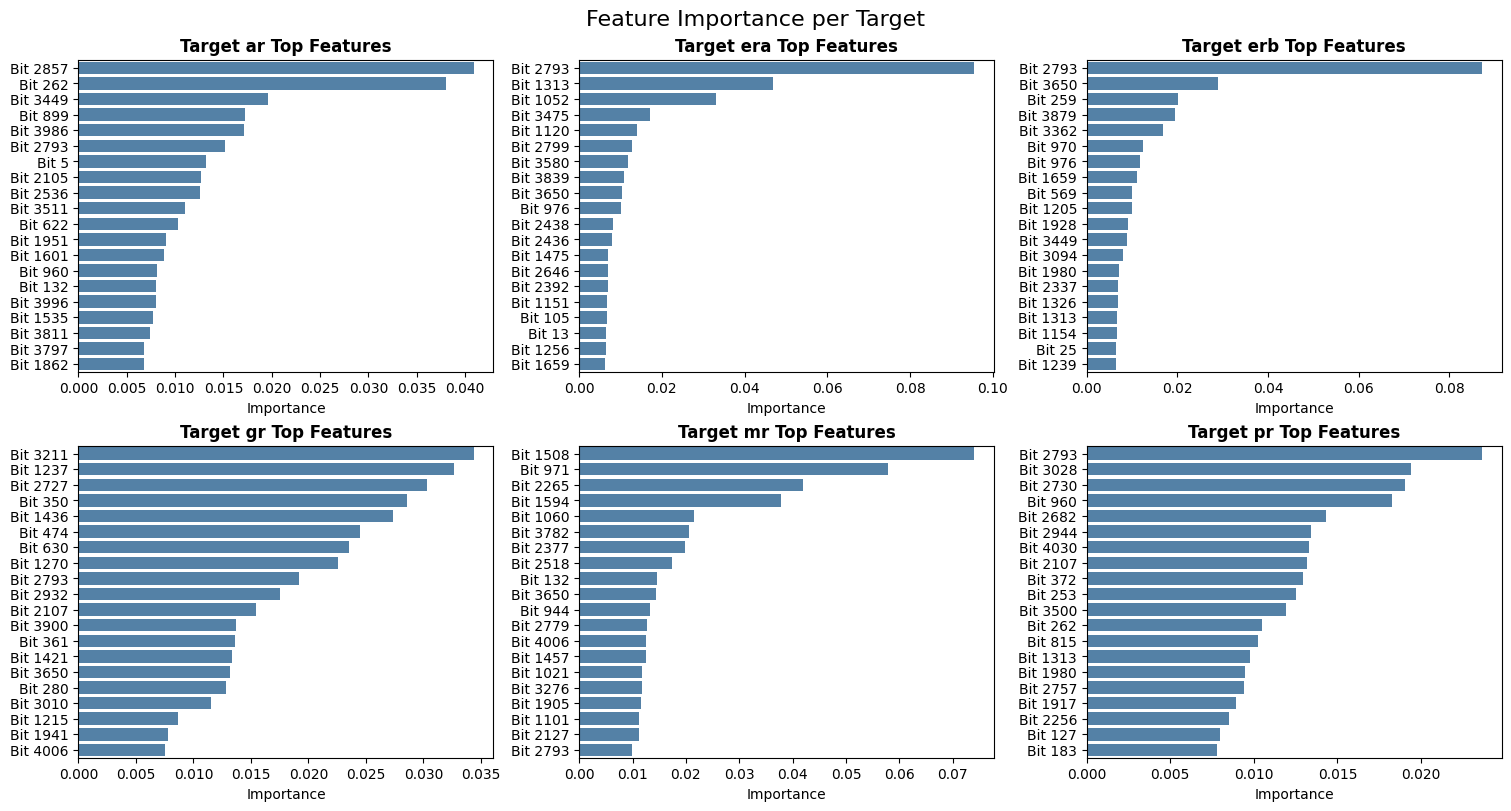

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from pathlib import Path

TOP_N = 20
COLS = 3
n_targets = len(feature_importance_matrix)
rows = math.ceil(n_targets / COLS)

fig, axes = plt.subplots(rows, COLS, figsize=(5 * COLS, 4 * rows), constrained_layout=True)
axes = axes.flatten()

print(f"Generating plots for {n_targets} targets...")

for i in range(n_targets):
    ax = axes[i]
    imp = feature_importance_matrix[i]
    top_indices = np.argsort(imp)[::-1][:TOP_N]
    top_values = imp[top_indices]
    labels = [f"Bit {idx}" for idx in top_indices]

    sns.barplot(x=top_values, y=labels, ax=ax, color='steelblue')
    ax.set_title(f"Target {target_names[i]} Top Features", fontsize=12, fontweight='bold')
    ax.set_xlabel("Importance")

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Feature Importance per Target", fontsize=16)
image_dir = Path("images")
image_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(image_dir / "xgb_shap_target_grid.png", dpi=300)
plt.show()

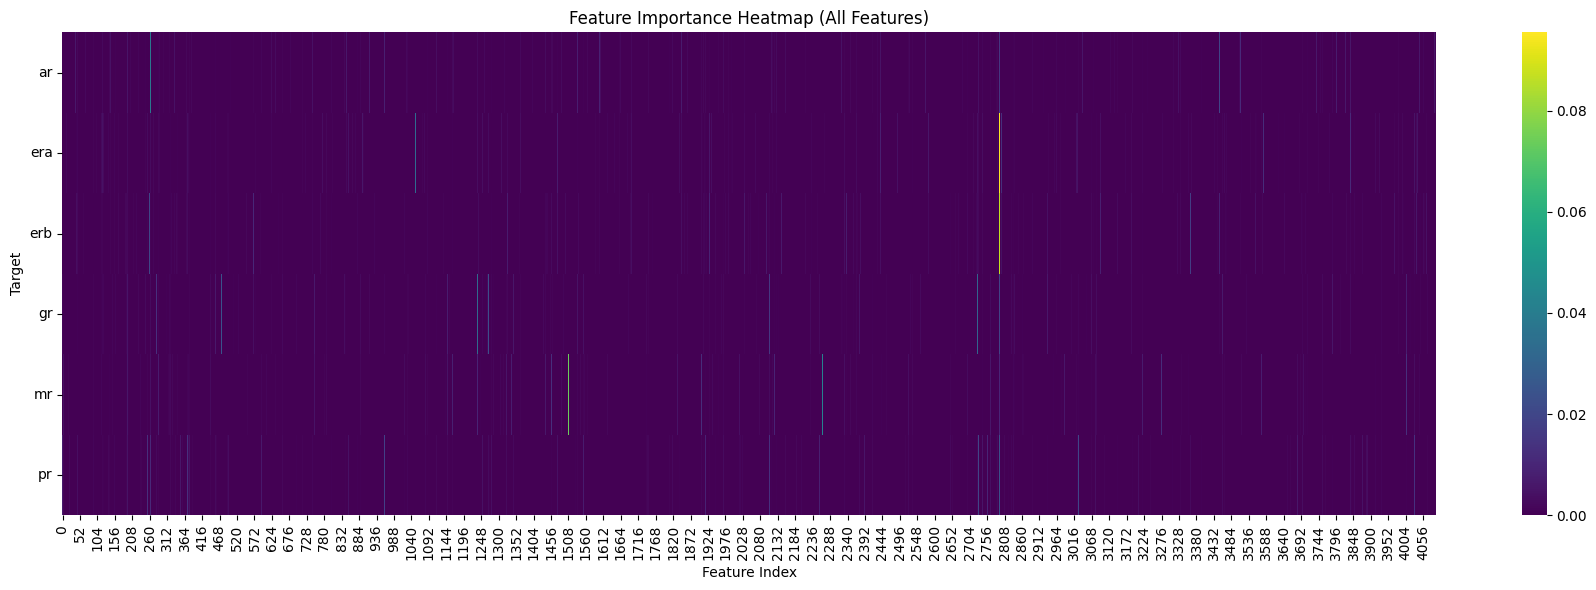

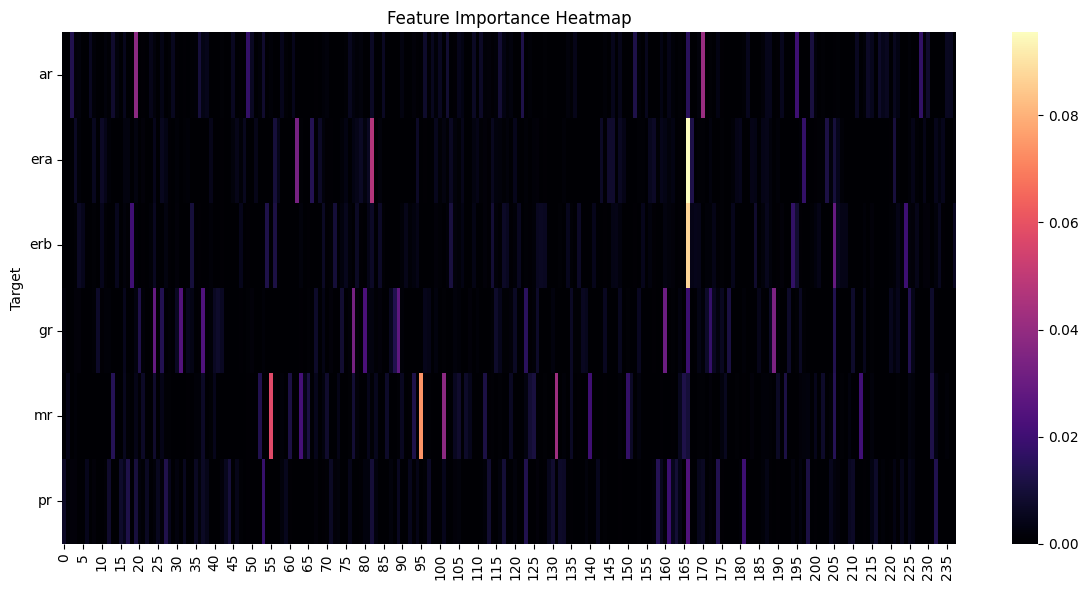

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

importance_matrix = np.vstack(feature_importance_matrix)

plt.figure(figsize=(18, 6))
sns.heatmap(
    importance_matrix,
    cmap="viridis",
    cbar=True
)
plt.yticks(ticks=np.arange(len(target_names)) + 0.5, labels=target_names, rotation=0)
plt.title("Feature Importance Heatmap (All Features)")
plt.xlabel("Feature Index")
plt.ylabel("Target")
plt.tight_layout()
plt.show()

selected_matrix = importance_matrix[:, final_selected_indices]

plt.figure(figsize=(12, 6))
sns.heatmap(
    selected_matrix,
    cmap="magma",
    cbar=True
)
plt.yticks(ticks=np.arange(len(target_names)) + 0.5, labels=target_names, rotation=0)
plt.title("Feature Importance Heatmap")
plt.ylabel("Target")
plt.tight_layout()
plt.show()